In [1]:
######Basic Optical Flow alignment code for time-series imaging dataset
from matplotlib import pyplot as plt
import numpy as np
import glob,os
import cv2
import tools_of as tools
plt.close('all')

In [2]:
dir_in=r'G:/bbso_ss_2024/data/20220517/vissr/sr/r080'
dir_in=r'G:/bbso_ss_2024/data/20200513/vissr/b080'
dir_in=r'G:/bbso_ss_2024/data/of_ts_test1'
# dir_out=os.path.dirname(dir_in)+'/of'
dir_out=dir_in+'/of/'
if not os.path.exists(dir_out):
    os.makedirs(dir_out)
filelist=sorted(glob.glob(dir_in+'/*.fts'))
tot=len(filelist)
nr=0#reference frame, 0==>nr
im0,h0=tools.fitsread(filelist[nr])
OT = h0['TIME-OBS']
T1 = tools.num_time(OT)

In [4]:
h,w=im0.shape
icube=np.zeros((tot,h,w))
#icube=np.zeros((tot,1800,2100))

In [5]:
for ii in range(tot):
    im,hd2= tools.fitsread(filelist[ii])
    OT = hd2['TIME-OBS']
    T2 = tools.num_time(OT)
    difT=T2-T1#+210*15#time difference to the reference frame, to do derotation
#    print(difT)
    rot = 360./24./3600.*difT  
    im = tools.imrotate(im,rot)#derotate
    print(filelist[ii])
    icube[ii,:,:]=im#[250:2050,200:2300]
    
ncube=tools.cubealign(icube.copy(),wd=100,winsize=31)
ncube=ncube.astype(np.uint16)

G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174300.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174301.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174302.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174303.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174304.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174305.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174306.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174307.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174308.fts
G:/gst_ss_2024/data/of_ts_test1\bbso_hab080_vissr_20200513_174309.fts
0.998 51670 [ 0.32240295 -0.09269714] [0.00346352 0.00332808]
shift: 0 0 [ 0.32240295 -0.09269714] 0.998
1.0 51744 [-0.35375977 -0.10348511] [0.00208404 0.00252267]
shift: 0 1 [-0.35375977 -0.10348511] 1.0
1.0 51755 [-0.06896973 -0.02810669] [0.00213395 0.00214575]
shift: 0 2 [-0.06896973 -0.0281066

In [6]:
tcube=[]
fn=[]
print('write fits')
for jj in range(tot):
    tcube.append(os.path.basename(filelist[jj]))
    nfn=dir_out+os.path.basename(filelist[jj])
    im,head= tools.fitsread(filelist[ii])
    tools.fitswrite(nfn,ncube[jj,:,:],head)   
    print(nfn)

write fits
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174300.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174301.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174302.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174303.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174304.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174305.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174306.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174307.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174308.fts
G:/gst_ss_2024/data/of_ts_test1/of/bbso_hab080_vissr_20200513_174309.fts


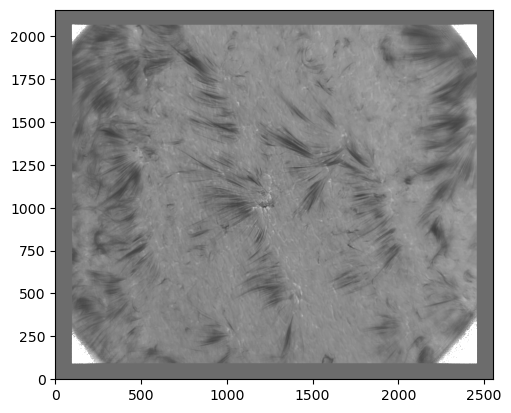

0 bbso_hab080_vissr_20200513_174300.fts


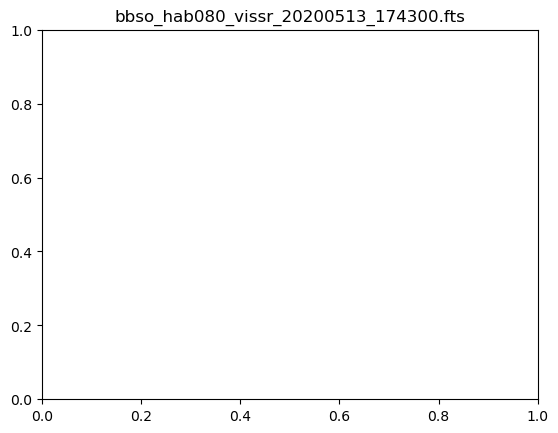

1 bbso_hab080_vissr_20200513_174301.fts


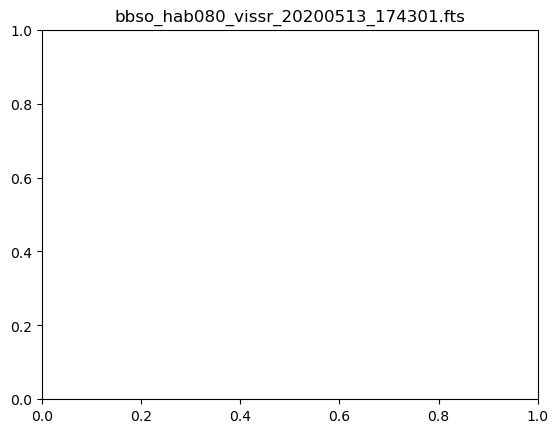

2 bbso_hab080_vissr_20200513_174302.fts


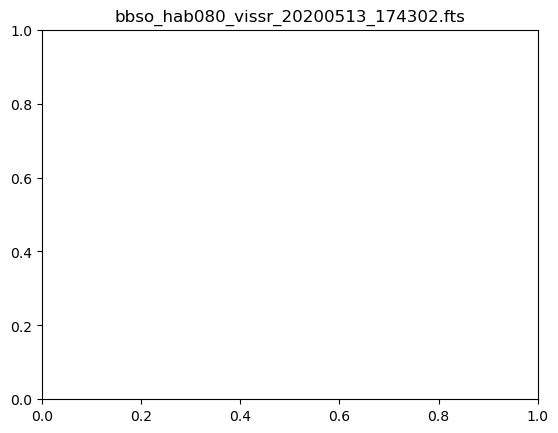

3 bbso_hab080_vissr_20200513_174303.fts


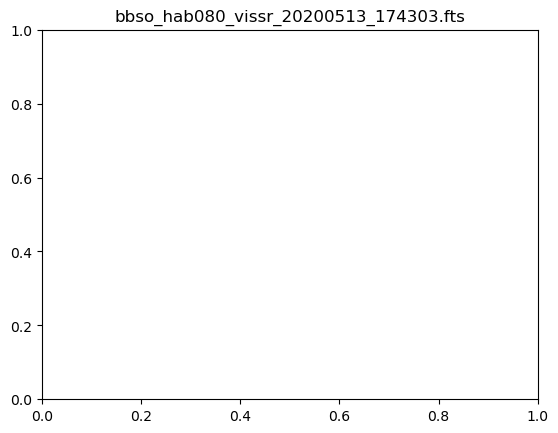

4 bbso_hab080_vissr_20200513_174304.fts


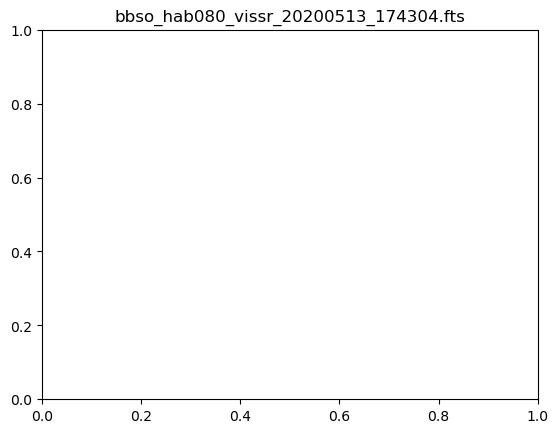

5 bbso_hab080_vissr_20200513_174305.fts


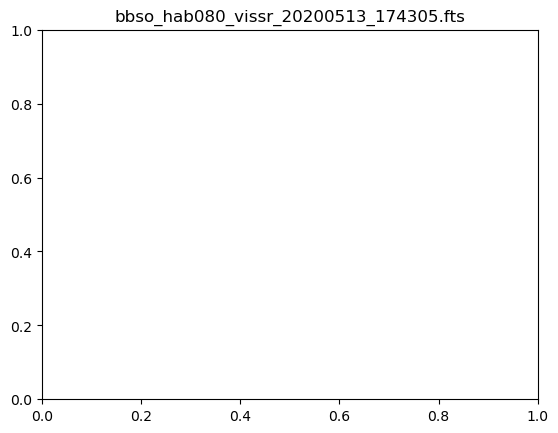

6 bbso_hab080_vissr_20200513_174306.fts


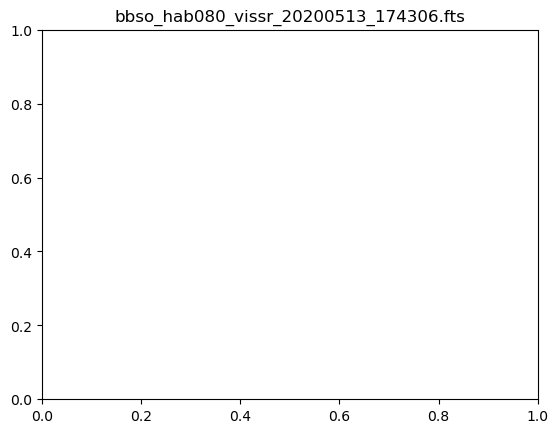

7 bbso_hab080_vissr_20200513_174307.fts


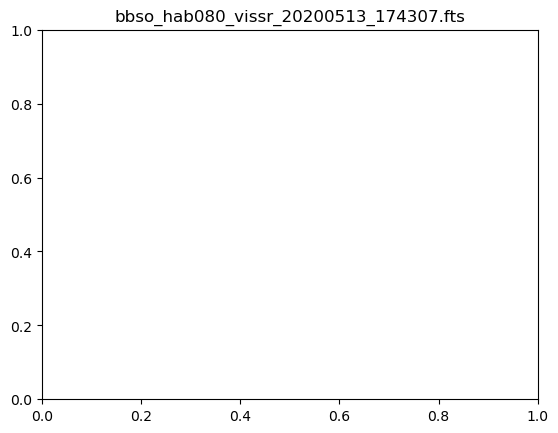

8 bbso_hab080_vissr_20200513_174308.fts


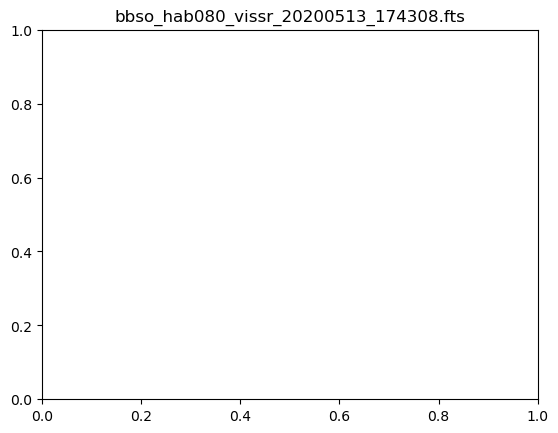

9 bbso_hab080_vissr_20200513_174309.fts
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174300.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174301.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174302.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174303.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174304.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174305.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174306.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174307.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174308.fts.jpg
/home/xuyang/tmp\bbso_hab080_vissr_20200513_174309.fts.jpg


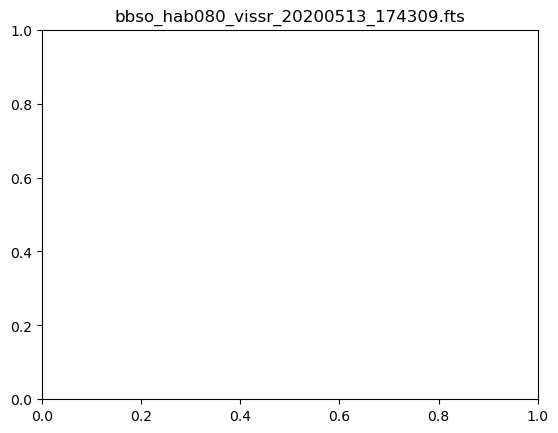

In [7]:
tools.array2movie(ncube,movie_name=dir_out+'of_moive',title_cube=tcube)